# LABORATORIUM 7 - NEURON

## 7.1 Uczenie i ewaluacja pojedynczego neuronu z logistyczną funkcją aktywacji

In [67]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.datasets import make_regression
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import auc, roc_curve
import time
from sklearn.model_selection import train_test_split
import pandas as pd

#### Funkcje generujące zbiory:

In [42]:
def generate_data(n_samples, n_features, random_state):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=random_state
    )
    # y = 2 * y - 1
    return X, y

def generate_moons(n_samples, random_state):
    X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.1, random_state=random_state)
    # y_moons = 2 * y_moons - 1
    
    return X_moons, y_moons

#### Funkcja do liczenia metryk i statystyk:

In [43]:
from matplotlib.colors import ListedColormap
from sklearn.metrics import ConfusionMatrixDisplay


def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[0,1], decision_plot=True):
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    if decision_plot:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    return accuracy, sensitivity, specificity, roc_auc


#### Implementacja Neuronu

In [44]:
class LogisticNeuron: 
    def __init__(self, eta=0.01, max_epochs=1000):
        self.weights = None
        self.bias = None
        self.eta = eta
        self.max_epochs = max_epochs
        self.losses = []

    def sigmoid(self, s):
        return 1 / (1 + np.exp(-s))

    def activate(self, X):
        s = np.dot(X, self.weights) + self.bias
        y = self.sigmoid(s)
        return y, s

    def train(self, X, y):
        self.weights = np.random.rand(X.shape[1]) * 0.01
        self.bias = np.random.rand() * 0.01

        for epoch in range(self.max_epochs):
            total_error = 0
            for i in range(X.shape[0]):
                y_pred, s = self.activate(X[i])
                
                error = y[i] - y_pred
                total_error += error ** 2

                grad = self.eta * error * y_pred * (1 - y_pred) * X[i]
                self.weights += grad

                self.bias = self.bias + self.eta * error * y_pred * (1 - y_pred)
            self.losses.append(total_error / X.shape[0])

    def predict(self, X):
        y, _ = self.activate(X)
        return (y >= 0.5).astype(int)        


#### Testowanie funkcji na zbiorze *Generate data*:

Czas wykonania: 4.024736 sekund
Neuron logistyczny na Generate data:
Skuteczność: 99.7500%
Czułość (Recall): 99.4872%
Swoistość: 100.0000%
ROC AUC: 0.9974


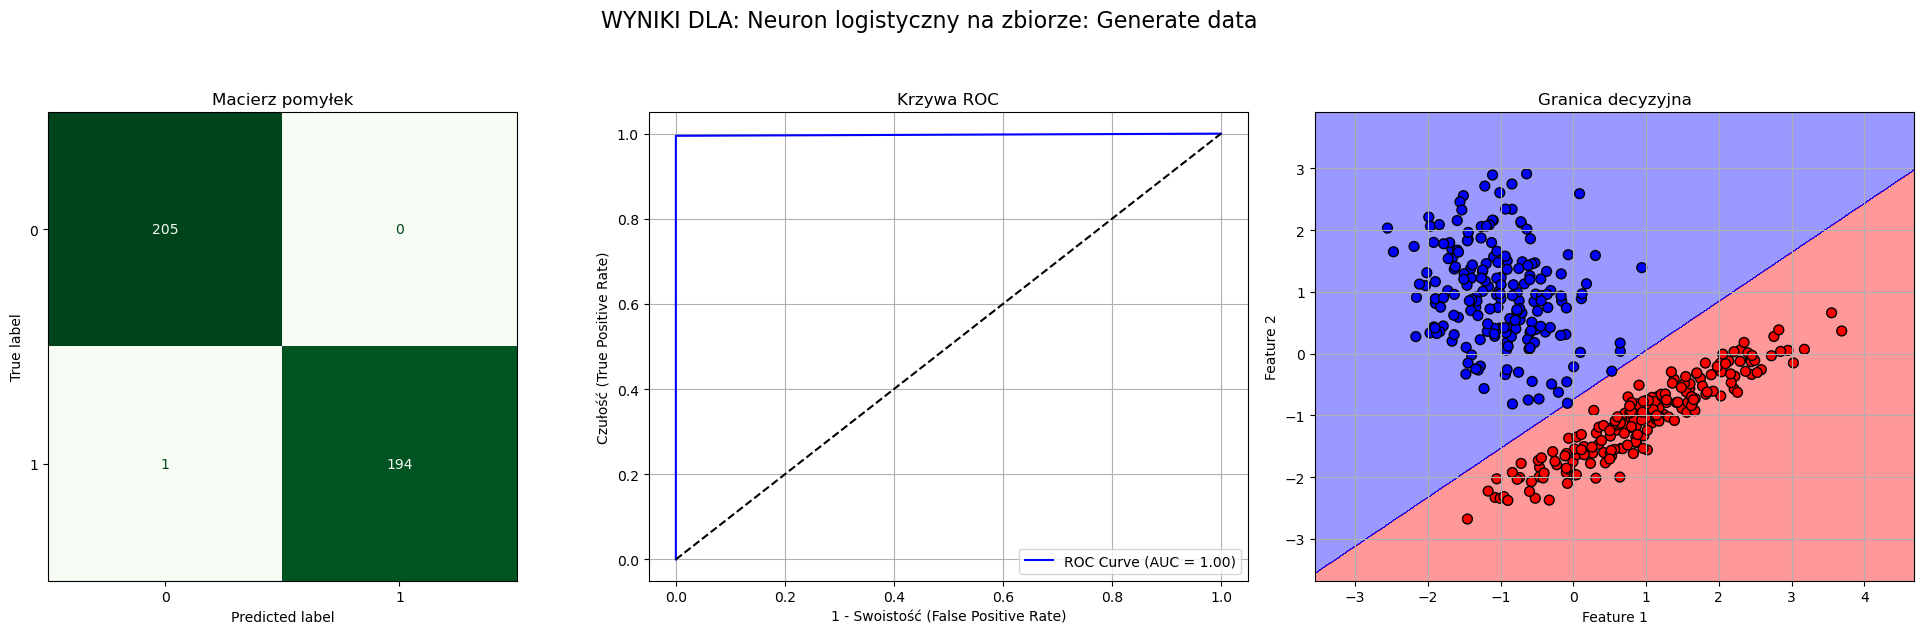

Wykres funkcji straty:


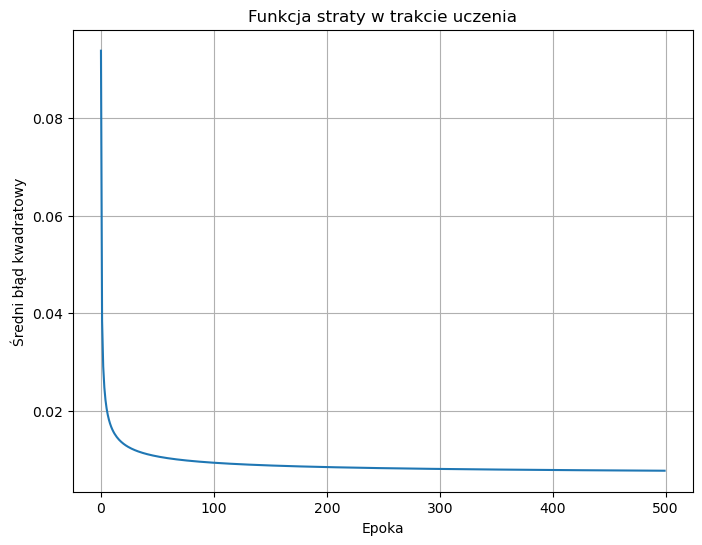

In [45]:
X_generate, y_generate = generate_data(2000, 2, 259195)
X_gen_train, X_gen_test, y_gen_train, y_gen_test = train_test_split(X_generate, y_generate, test_size=0.2, random_state=259195)

start = time.time()
for _ in range(1):
    neuron = LogisticNeuron(eta=0.01, max_epochs=500)
    neuron.train(X_gen_train, y_gen_train)
    y_gen_pred = neuron.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
evaluate_classifier(y_gen_test, y_gen_pred, X_gen_test, y_gen_test, neuron, "Neuron logistyczny", "Generate data", labels=[0, 1], decision_plot=True)

print("Wykres funkcji straty:")
plt.figure(figsize=(8, 6))
plt.plot(neuron.losses)
plt.title("Funkcja straty w trakcie uczenia")
plt.xlabel("Epoka")
plt.ylabel("Średni błąd kwadratowy")
plt.grid(True)

#### Testowanie na *make moons*:

Czas wykonania: 3.962712 sekund
Neuron logistyczny na Moons data:
Skuteczność: 87.0000%
Czułość (Recall): 83.1579%
Swoistość: 90.4762%
ROC AUC: 0.8682


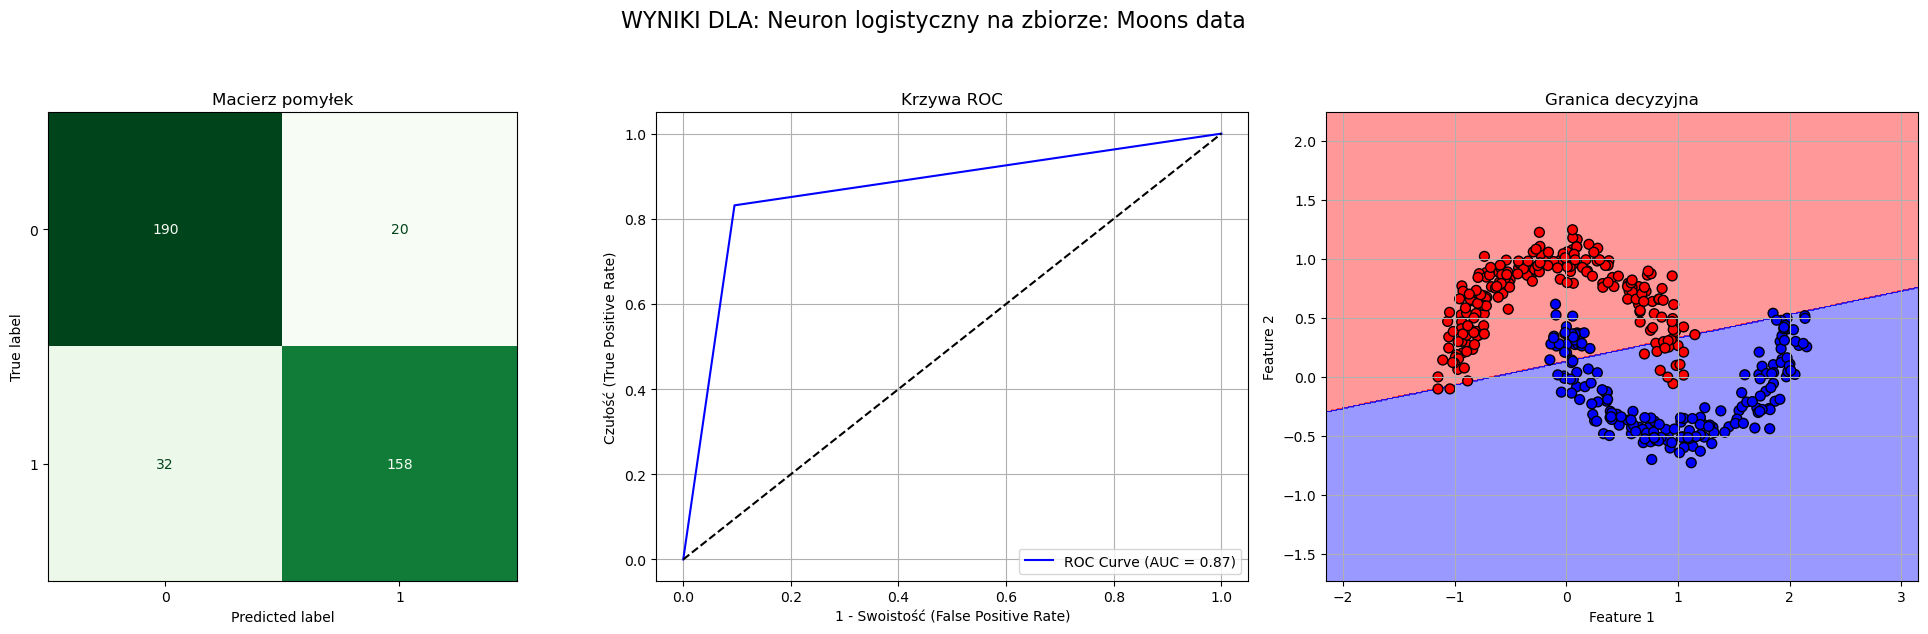

Wykres funkcji straty dla danych Moons:


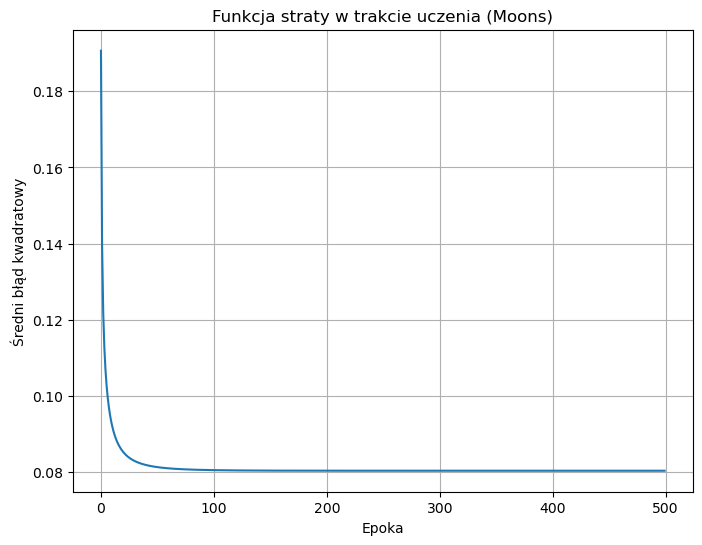

In [46]:
X_moons, y_moons = generate_moons(2000, 259195)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=259195)

start = time.time()
for _ in range(1):
    neuron_moons = LogisticNeuron(eta=0.01, max_epochs=500)
    neuron_moons.train(X_m_train, y_m_train)
    y_m_pred = neuron_moons.predict(X_m_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
evaluate_classifier(y_m_test, y_m_pred, X_m_test, y_m_test, neuron_moons, "Neuron logistyczny", "Moons data", labels=[0, 1], decision_plot=True)
print("Wykres funkcji straty dla danych Moons:")
plt.figure(figsize=(8, 6))
plt.plot(neuron_moons.losses)
plt.title("Funkcja straty w trakcie uczenia (Moons)")
plt.xlabel("Epoka")
plt.ylabel("Średni błąd kwadratowy")
plt.grid(True)


## 3.2 Uczenie i ewaluacja z aktywacjami: Heaviside, sin, tanh, sign, ReLu, leaky ReLu

In [47]:
class Neuron: 
    def __init__(self, act_fun='logistic', eta=0.01, max_epochs=1000):
        self.act_function = act_fun
        self.weights = None
        self.bias = None
        self.eta = eta
        self.max_epochs = max_epochs
        self.losses = []

    def act_logistic(self, X):
        def sigmoid(self, s):
            return 1 / (1 + np.exp(-s))
        s = np.dot(X, self.weights) + self.bias
        y = sigmoid(s)
        return y, s
    
    def act_heaviside(self, X):
        s = np.dot(X, self.weights) + self.bias
        y = np.where(s >= 0, 1, 0)
        return y, s
    
    def act_sin(self, X):
        s = np.dot(X, self.weights) + self.bias
        y = np.sin(s)
        return y, s
    
    def act_tan(self, X):
        s = np.dot(X, self.weights) + self.bias
        y = np.tan(s)
        return y, s
    
    def act_relu(self, X):
        s = np.dot(X, self.weights) + self.bias
        y = np.maximum(0, s)
        return y, s
    
    def act_leaky_relu(self, X):
        s = np.dot(X, self.weights) + self.bias
        y = np.where(s > 0, s, 0.01 * s)
        return y, s
    
    def act_sign(self, X):
        s = np.dot(X, self.weights) + self.bias
        y = np.sign(s)
        return y, s
    
    def activate(self, X):
        if self.act_function == 'logistic':
            return self.act_logistic(X)
        elif self.act_function == 'heaviside':
            return self.act_heaviside(X)
        elif self.act_function == 'sin':
            return self.act_sin(X)
        elif self.act_function == 'tanh':
            return self.act_tan(X)  
        elif self.act_function == 'relu':
            return self.act_relu(X)
        elif self.act_function == 'leaky_relu':
            return self.act_leaky_relu(X)
        elif self.act_function == 'sign':
            return self.act_sign(X)
        
    def derivative(self, y_pred):
        if self.act_function == 'logistic':
            return y_pred * (1 - y_pred)
        elif self.act_function == 'heaviside':
            return np.ones(y_pred.shape)
        elif self.act_function == 'sin':
            return np.cos(y_pred)
        elif self.act_function == 'tanh':
            return 1 / (np.cos(y_pred) ** 2)
        elif self.act_function == 'relu':
            return np.where(y_pred > 0, 1, 0)
        elif self.act_function == 'leaky_relu':
            return np.where(y_pred > 0, 1, 0.01)
        elif self.act_function == 'sign':
            return np.ones(y_pred.shape)
        

    def train(self, X, y):
        self.weights = np.random.rand(X.shape[1]) * 0.01
        self.bias = np.random.rand() * 0.01

        for epoch in range(self.max_epochs):
            total_error = 0
            for i in range(X.shape[0]):
                y_pred, s = self.activate(X[i])
                
                error = y[i] - y_pred
                total_error += error ** 2

                grad = self.eta * error * self.derivative(s) * X[i]
                self.weights += grad

                self.bias = self.bias + self.eta * error * self.derivative(s)
            self.losses.append(total_error / X.shape[0])

    def predict(self, X):
        y, _ = self.activate(X)
        return (y >= 0.5).astype(int)        


#### Ponowne przygotowanie zbiorów:

In [48]:
X_generate, y_generate = generate_data(2000, 2, 259195)
X_gen_train, X_gen_test, y_gen_train, y_gen_test = train_test_split(X_generate, y_generate, test_size=0.2, random_state=259195)

results = {}

### Test dla różnych funkcji aktywacji: 

#### *Heaviside*:

Czas wykonania: 12.252728 sekund
Neuron Heaviside na Generate data:
Skuteczność: 99.5000%
Czułość (Recall): 99.4872%
Swoistość: 99.5122%
ROC AUC: 0.9950


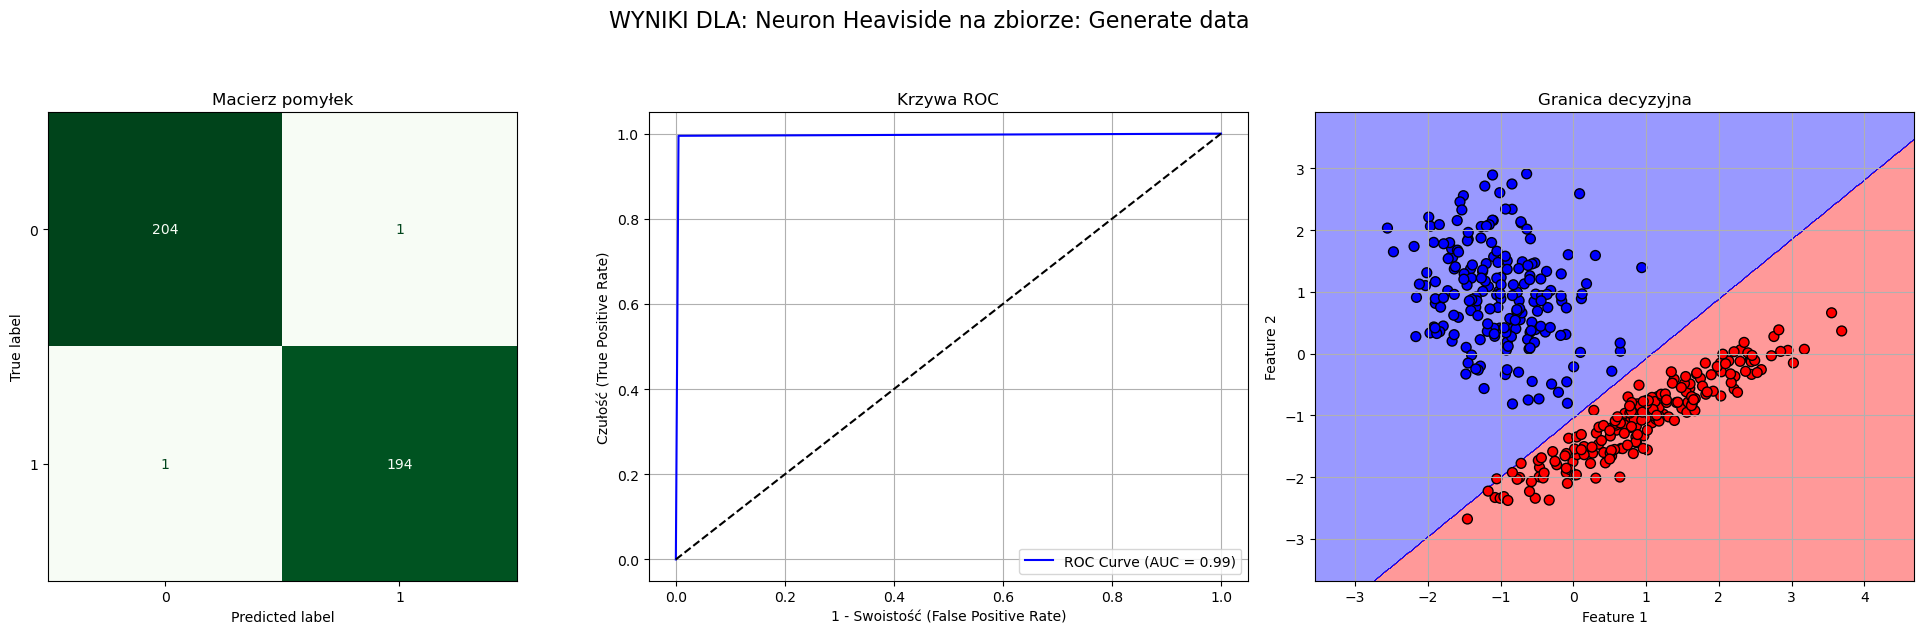

In [60]:
start = time.time()
for _ in range(1):
    heaviside_neuron = Neuron(act_fun='heaviside', eta=0.01, max_epochs=500)
    heaviside_neuron.train(X_gen_train, y_gen_train)
    heaviside_y_pred = heaviside_neuron.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
acc, sens, spec, roc = evaluate_classifier(y_gen_test, heaviside_y_pred, X_gen_test, y_gen_test, heaviside_neuron, "Neuron Heaviside", "Generate data", labels=[0, 1], decision_plot=True)

results['heaviside'] = (acc, sens, spec, roc)

#### *Sinus*:

Czas wykonania: 5.394805 sekund
Neuron Sinus na Generate data:
Skuteczność: 98.7500%
Czułość (Recall): 97.4359%
Swoistość: 100.0000%
ROC AUC: 0.9872


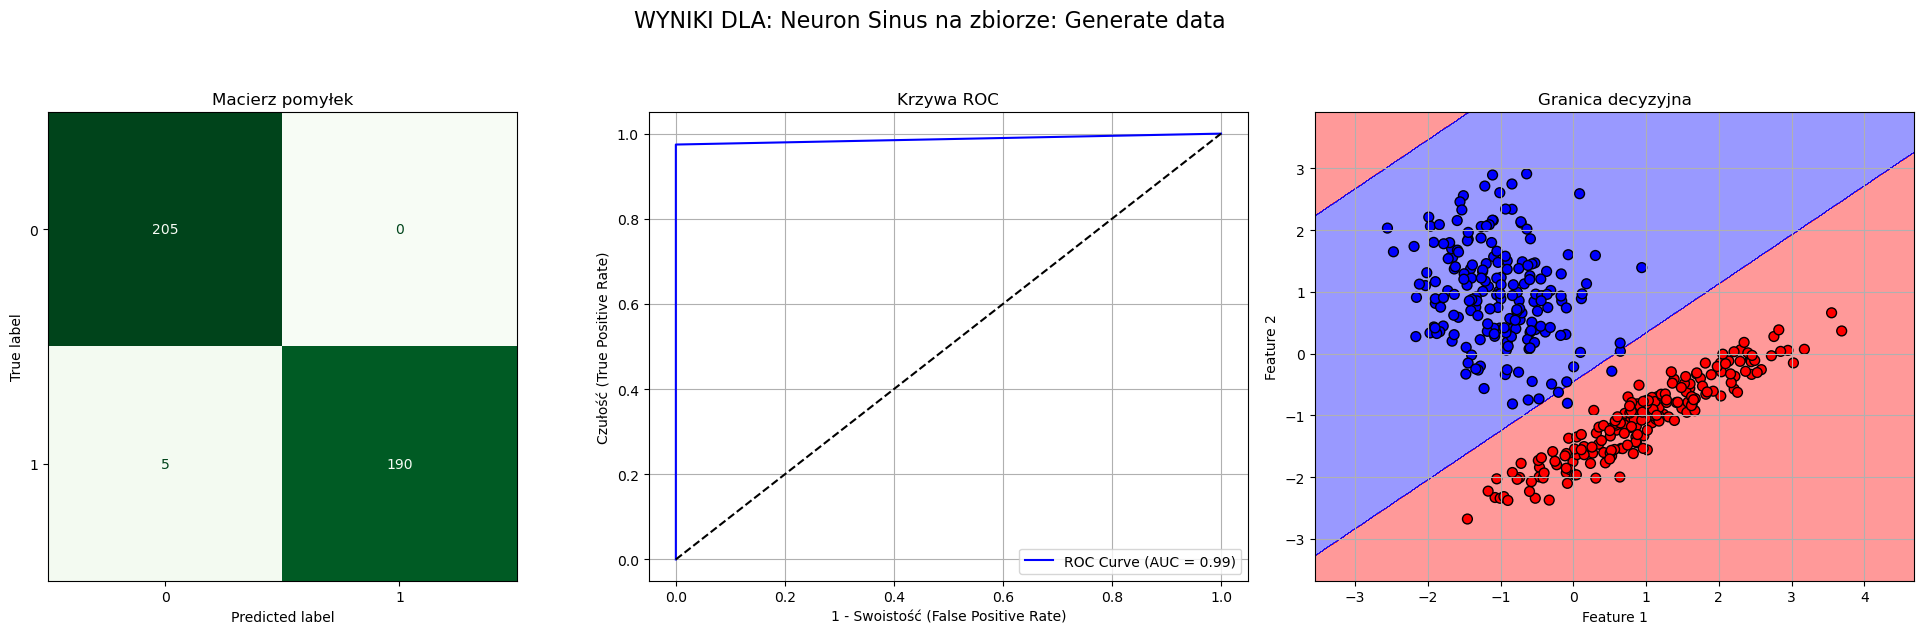

In [59]:
start = time.time()
for _ in range(1):
    sin_neuron = Neuron(act_fun='sin', eta=0.01, max_epochs=500)
    sin_neuron.train(X_gen_train, y_gen_train)
    sin_y_pred = sin_neuron.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
acc, sens, spec, roc = evaluate_classifier(y_gen_test, sin_y_pred, X_gen_test, y_gen_test, sin_neuron, "Neuron Sinus", "Generate data", labels=[0, 1], decision_plot=True)

results['sinus'] = (acc, sens, spec, roc)

Czas wykonania: 5.571522 sekund
Neuron Tanh na Generate data:
Skuteczność: 95.7500%
Czułość (Recall): 91.2821%
Swoistość: 100.0000%
ROC AUC: 0.9564


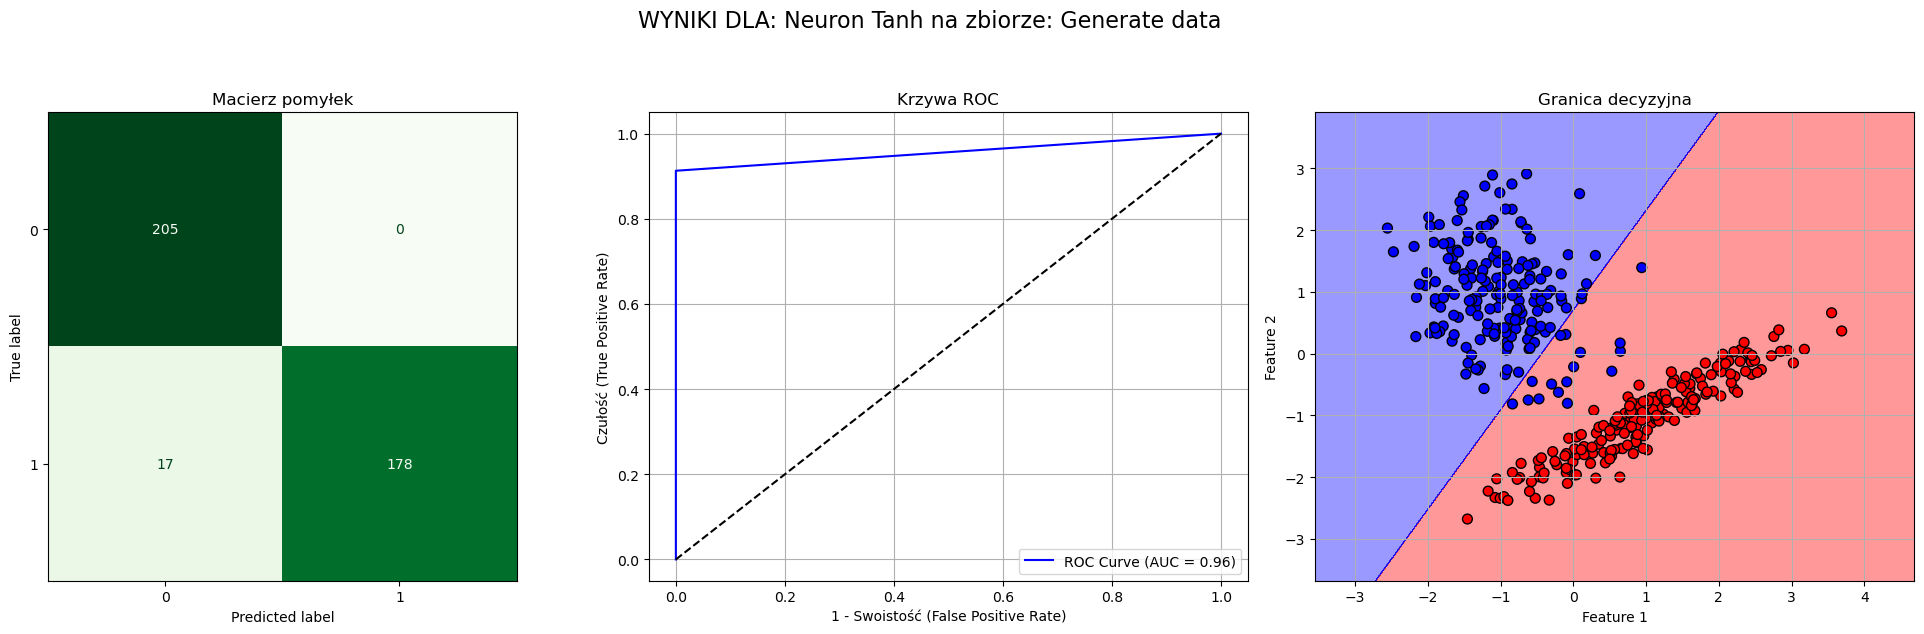

In [61]:
start = time.time()
for _ in range(1):
    tanh_neuron = Neuron(act_fun='tanh', eta=0.01, max_epochs=500)
    tanh_neuron.train(X_gen_train, y_gen_train)
    tanh_y_pred = tanh_neuron.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
acc, sens, spec, roc = evaluate_classifier(y_gen_test, tanh_y_pred, X_gen_test, y_gen_test, tanh_neuron, "Neuron Tanh", "Generate data", labels=[0, 1], decision_plot=True)

results['tanh'] = (acc, sens, spec, roc)

#### *sign*:

Czas wykonania: 8.141097 sekund
Neuron Sign na Generate data:
Skuteczność: 73.7500%
Czułość (Recall): 100.0000%
Swoistość: 48.7805%
ROC AUC: 0.7439


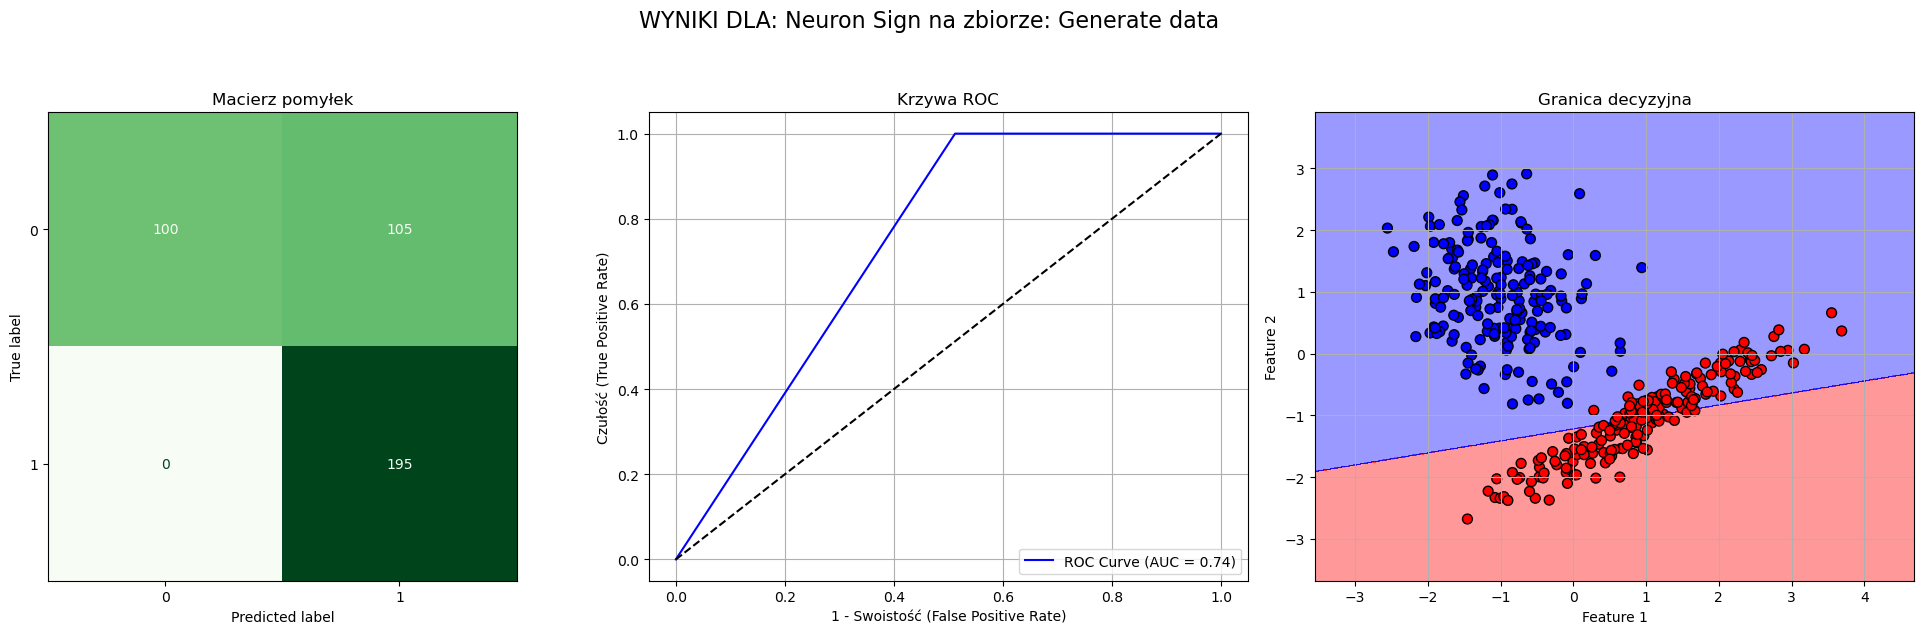

In [62]:
start = time.time()
for _ in range(1):
    sign_neuron = Neuron(act_fun='sign', eta=0.01, max_epochs=500)
    sign_neuron.train(X_gen_train, y_gen_train)
    sign_y_pred = sign_neuron.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
acc, sens, spec, roc = evaluate_classifier(y_gen_test, sign_y_pred, X_gen_test, y_gen_test, sign_neuron, "Neuron Sign", "Generate data", labels=[0, 1], decision_plot=True)

results['sign'] = (acc, sens, spec, roc)

#### *ReLU*:

Czas wykonania: 10.969338 sekund
Neuron ReLU na Generate data:
Skuteczność: 96.7500%
Czułość (Recall): 93.3333%
Swoistość: 100.0000%
ROC AUC: 0.9667


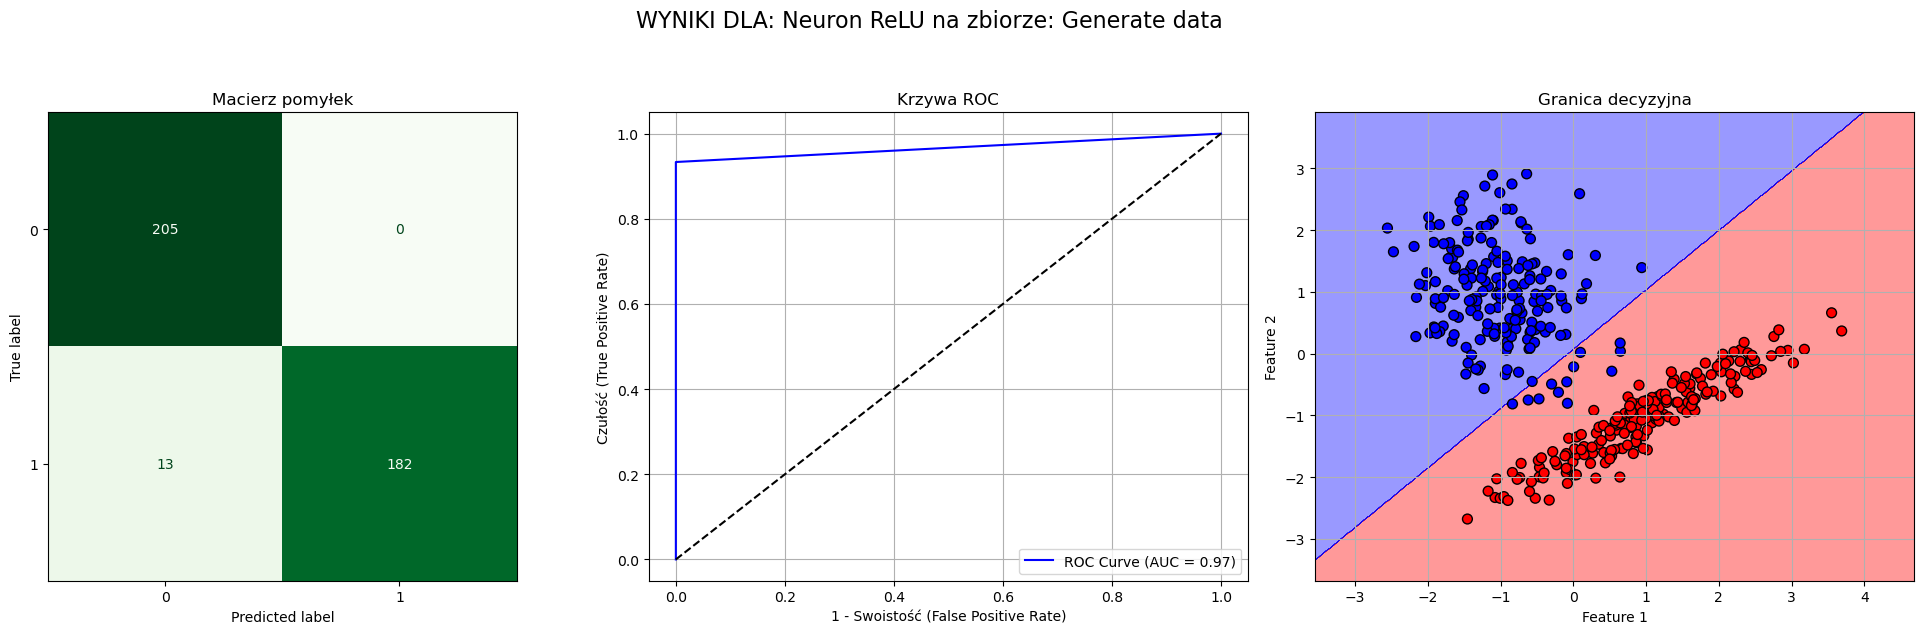

In [63]:
start = time.time()
for _ in range(1):
    relu_neuron = Neuron(act_fun='relu', eta=0.01, max_epochs=500)
    relu_neuron.train(X_gen_train, y_gen_train)
    y_gen_pred = relu_neuron.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
acc, sens, spec, roc = evaluate_classifier(y_gen_test, y_gen_pred, X_gen_test, y_gen_test, relu_neuron, "Neuron ReLU", "Generate data", labels=[0, 1], decision_plot=True)

results['relu'] = (acc, sens, spec, roc)

#### *Leaky ReLU*:

Czas wykonania: 13.264562 sekund
Neuron LeakyReLU na Generate data:
Skuteczność: 96.7500%
Czułość (Recall): 93.3333%
Swoistość: 100.0000%
ROC AUC: 0.9667


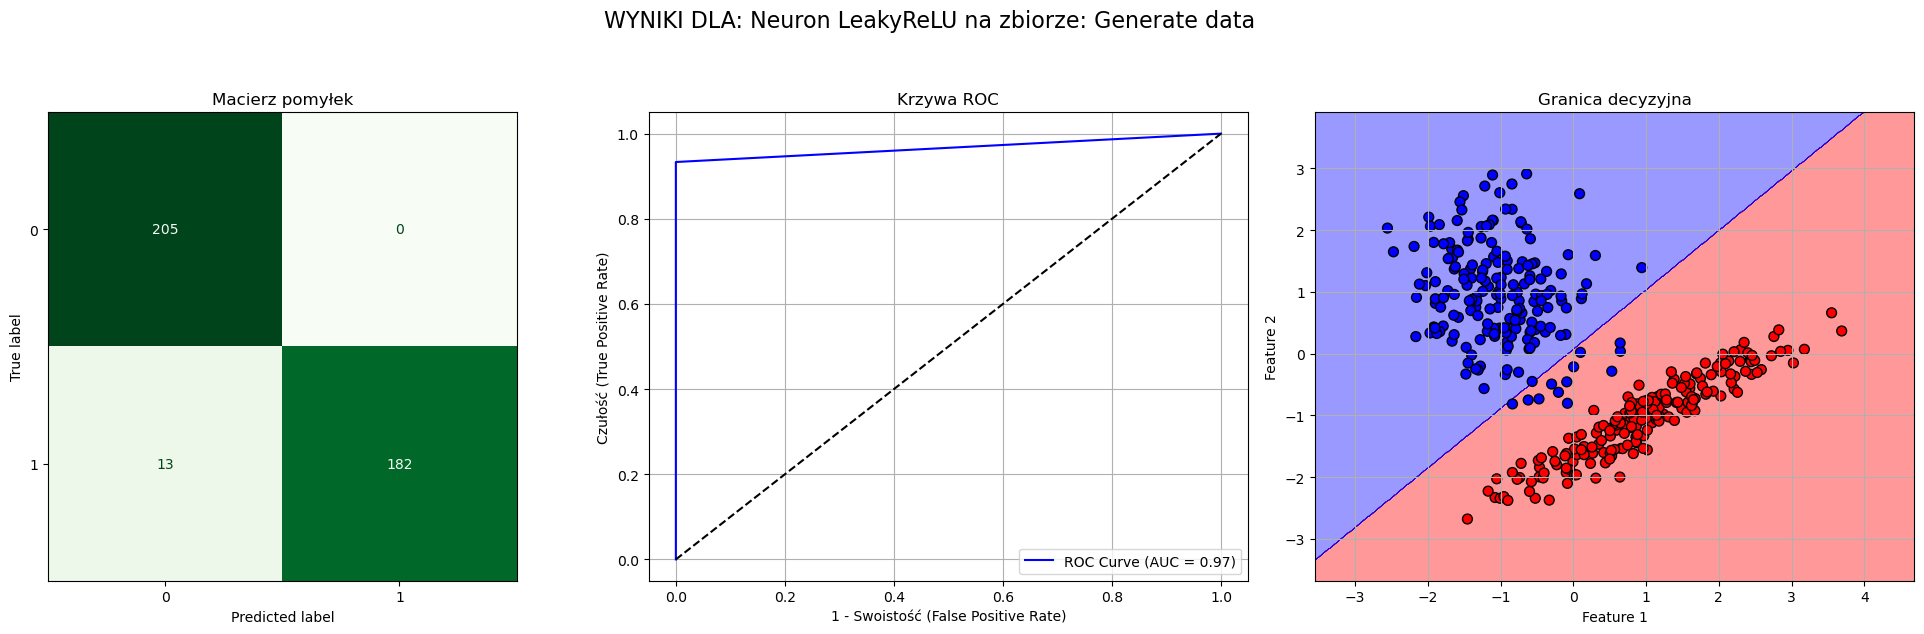

In [64]:
start = time.time()
for _ in range(1):
    leaky_neuron = Neuron(act_fun='leaky_relu', eta=0.01, max_epochs=500)
    leaky_neuron.train(X_gen_train, y_gen_train)
    leaky_y_pred = leaky_neuron.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
acc, sens, spec, roc = evaluate_classifier(y_gen_test, leaky_y_pred, X_gen_test, y_gen_test, leaky_neuron, "Neuron LeakyReLU", "Generate data", labels=[0, 1], decision_plot=True)

results['leaky_relu'] = (acc, sens, spec, roc)

#### Tablica z wynikami:

In [68]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy', 'Sensitivity', 'Specificity', 'ROC AUC'])

results_df

,Accuracy,Sensitivity,Specificity,ROC AUC
heaviside,0.9950,0.994872,0.995122,0.994997
sinus,0.9875,0.974359,1.000000,0.987179
tanh,0.9575,0.912821,1.000000,0.956410
sign,0.7375,1.000000,0.487805,0.743902
relu,0.9675,0.933333,1.000000,0.966667
leaky_relu,0.9675,0.933333,1.000000,0.966667
